In [13]:
import glob
import os
import re
from datetime import datetime

import cv2
import h5py
import json
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import yaml


from PIL import Image
from tqdm import tqdm
from pathlib import Path


from MirrorExtractor.simple_mirror_extractor import SimpleMirrorExtractor

In [25]:
def add_polygon_on_img(ax, points_list, color):
    for points in points_list:
        # === Polygon na podstawie 4 współrzędnych ===
        polygon = patches.Polygon(
                points,
                closed=True,
                linewidth=2,
                edgecolor=color,
                facecolor=color,
                alpha=0.3  # przezroczystość wypełnienia
            )
        ax.add_patch(polygon)
    return ax

/home/pgliwny/Praca/Computer_vision_for_MAGIC/data/data/webcam_img/image_2024-05-06_1000.jpg


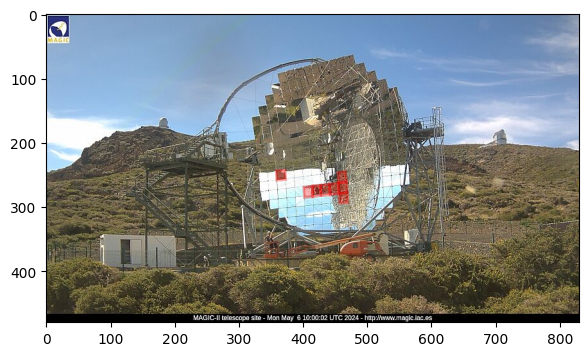

/home/pgliwny/Praca/Computer_vision_for_MAGIC/data/data/webcam_img/image_2024-05-06_1100.jpg


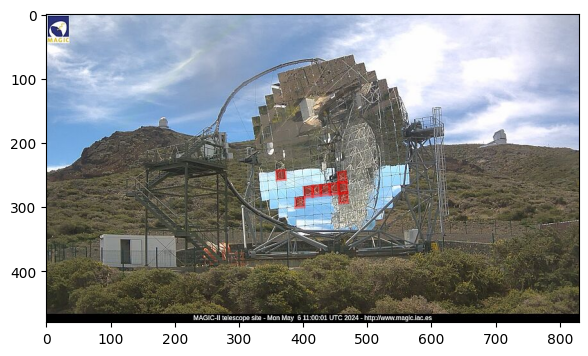

/home/pgliwny/Praca/Computer_vision_for_MAGIC/data/data/webcam_img/image_2024-05-06_1400.jpg


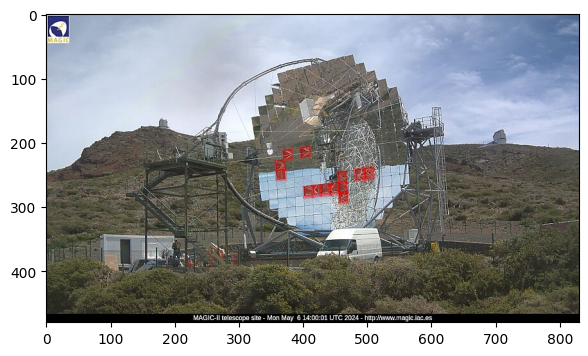

/home/pgliwny/Praca/Computer_vision_for_MAGIC/data/data/webcam_img/image_2024-05-06_1500.jpg


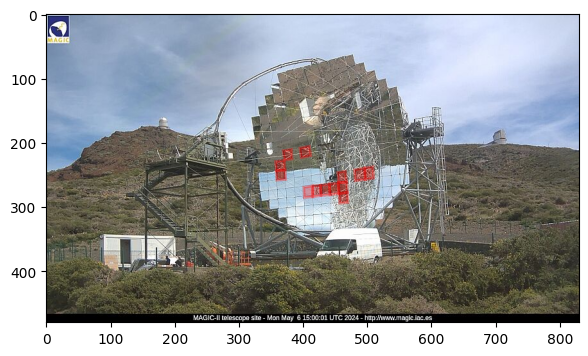

/home/pgliwny/Praca/Computer_vision_for_MAGIC/data/data/webcam_img/image_2024-05-06_1700.jpg


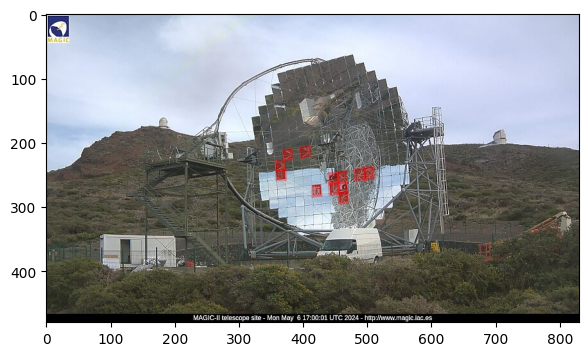

/home/pgliwny/Praca/Computer_vision_for_MAGIC/data/data/webcam_img/image_2024-05-06_1800.jpg
/home/pgliwny/Praca/Computer_vision_for_MAGIC/data/data/webcam_img/image_2024-05-07_1000.jpg
/home/pgliwny/Praca/Computer_vision_for_MAGIC/data/data/webcam_img/image_2024-05-07_1100.jpg
/home/pgliwny/Praca/Computer_vision_for_MAGIC/data/data/webcam_img/image_2024-05-07_1200.jpg


In [33]:
json_path = "/home/pgliwny/Praca/Computer_vision_for_MAGIC/data/annotations/img_with_annomarly.json"
webcam_img_dir = Path("/home/pgliwny/Praca/Computer_vision_for_MAGIC/data/data/webcam_img/")
calib_file = Path("/home/pgliwny/Praca/Computer_vision_for_MAGIC/data/calibration/points_WebCam.json")
mirror_extractor = SimpleMirrorExtractor(calib_file)

with open(json_path, "r") as f:
    dict_test_img_list = json.load(f)

for d in dict_test_img_list:
    img_path = webcam_img_dir / d["file"]
    print(img_path)
    if img_path.exists():
        img = cv2.imread(str(img_path))
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        points = [mirror_extractor.get_point_coords(mirror_id) for mirror_id in d['marked_mirrors']]

        fig, ax = plt.subplots(figsize=(8, 4))
        ax.imshow(img_rgb)
        add_polygon_on_img(ax, points, "red")
        plt.imshow(img_rgb)
        plt.show()